=== SVM WITHOUT SCALING ===
Accuracy: 0.8714
              precision    recall  f1-score   support

   Gas Giant       0.93      0.95      0.94       433
Neptune-like       0.80      0.64      0.71       270
 Super-Earth       0.83      0.91      0.87       549
 Terrestrial       0.93      0.89      0.91       249

    accuracy                           0.87      1501
   macro avg       0.87      0.85      0.86      1501
weighted avg       0.87      0.87      0.87      1501


=== SVM WITH SCALING ===
Accuracy: 0.8681
              precision    recall  f1-score   support

   Gas Giant       0.94      0.95      0.95       433
Neptune-like       0.79      0.64      0.71       270
 Super-Earth       0.82      0.91      0.86       549
 Terrestrial       0.93      0.88      0.90       249

    accuracy                           0.87      1501
   macro avg       0.87      0.85      0.86      1501
weighted avg       0.87      0.87      0.87      1501


Approximate feature importance (mean |coe

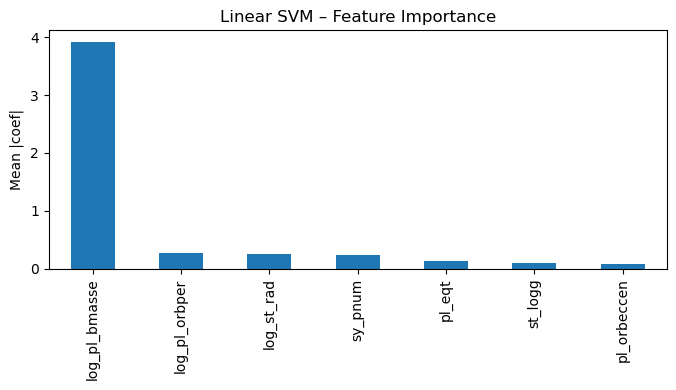


Top influential features: ['log_pl_bmasse', 'log_pl_orbper', 'log_st_rad']


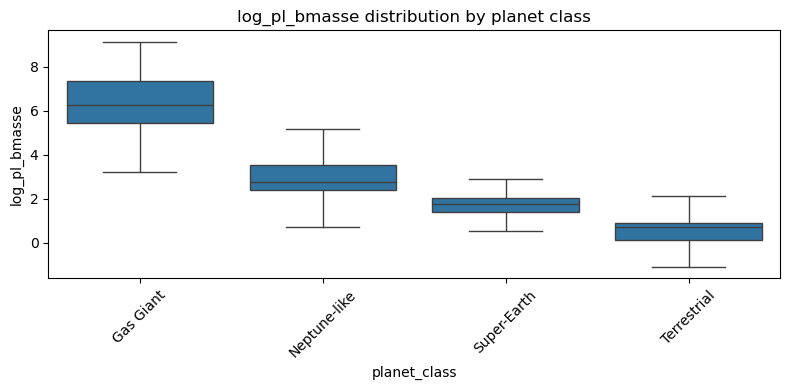

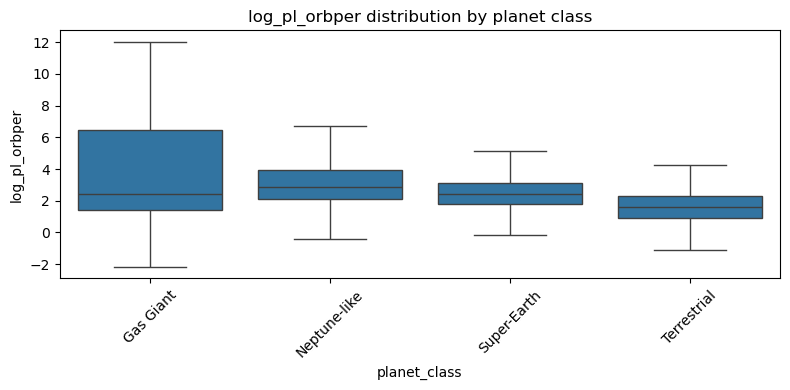

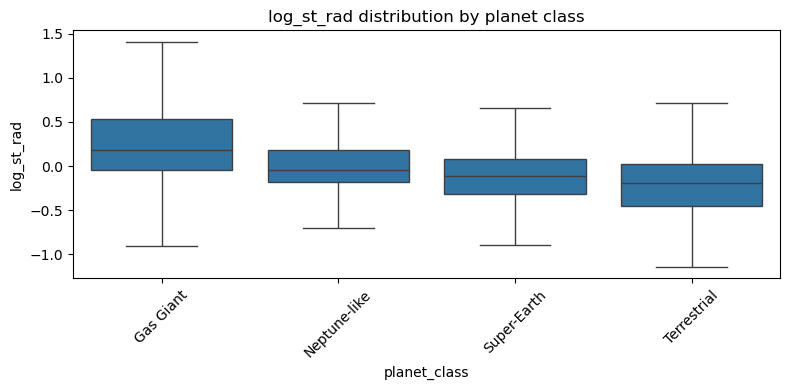

In [1]:
# Q3 – Explore which features are the most important in classification of exoplanets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# ---------------------------
# 0. Load data
# ---------------------------
df = pd.read_csv("exoplanet.csv")

# ---------------------------
# 1. Create log columns (SAFE)
# ---------------------------

# Replace <=0 values before log
df["pl_bmasse"] = pd.to_numeric(df["pl_bmasse"], errors="coerce")
df["pl_orbper"] = pd.to_numeric(df["pl_orbper"], errors="coerce")
df["st_rad"] = pd.to_numeric(df["st_rad"], errors="coerce")

df["pl_bmasse"] = df["pl_bmasse"].replace(0, np.nan)
df["pl_orbper"] = df["pl_orbper"].replace(0, np.nan)
df["st_rad"] = df["st_rad"].replace(0, np.nan)

df["log_pl_bmasse"] = np.log(df["pl_bmasse"])
df["log_pl_orbper"] = np.log(df["pl_orbper"])
df["log_st_rad"] = np.log(df["st_rad"])

# ---------------------------
# 2. Select features and target
# ---------------------------

feature_cols = [
    "pl_orbeccen",
    "pl_eqt",
    "st_logg",
    "sy_pnum",
    "log_pl_bmasse",
    "log_pl_orbper",
    "log_st_rad",
]

target_col = "planet_class"

df_model = df[feature_cols + [target_col]].copy()

df_model = df_model.dropna(subset=[target_col])

df_model[feature_cols] = df_model[feature_cols].apply(pd.to_numeric, errors="coerce")
df_model[feature_cols] = df_model[feature_cols].fillna(df_model[feature_cols].median())

X = df_model[feature_cols].values
y = df_model[target_col].astype(str).values

# ---------------------------
# 3. Train–test split
# ---------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42,
)

# ---------------------------
# 4. Linear SVM WITHOUT scaling
# ---------------------------

svc_noscale = SVC(kernel="linear", C=1.0, random_state=42)
svc_noscale.fit(X_train, y_train)
y_pred_ns = svc_noscale.predict(X_test)

print("=== SVM WITHOUT SCALING ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_ns), 4))
print(classification_report(y_test, y_pred_ns))

# ---------------------------
# 5. Linear SVM WITH scaling
# ---------------------------

pipe_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="linear", C=1.0, random_state=42)),
])

pipe_scaled.fit(X_train, y_train)
y_pred_s = pipe_scaled.predict(X_test)

print("\n=== SVM WITH SCALING ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_s), 4))
print(classification_report(y_test, y_pred_s))

# ---------------------------
# 6. Feature importance
# ---------------------------

svc_linear = pipe_scaled.named_steps["svc"]
coefs = np.abs(svc_linear.coef_)
mean_importance = coefs.mean(axis=0)

feat_importance = pd.Series(mean_importance, index=feature_cols).sort_values(ascending=False)

print("\nApproximate feature importance (mean |coef| across classes):")
print(feat_importance)

plt.figure(figsize=(7, 4))
feat_importance.plot(kind="bar")
plt.title("Linear SVM – Feature Importance")
plt.ylabel("Mean |coef|")
plt.tight_layout()
plt.show()

# ---------------------------
# 7. Visualize top features
# ---------------------------

top_feats = feat_importance.index[:3]

print("\nTop influential features:", top_feats.tolist())

for col in top_feats:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_model, x=target_col, y=col, showfliers=False)
    plt.title(f"{col} distribution by planet class")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
